# **Importation des bibliothèques nécessaire**

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA, KernelPCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

# **Chargement du dataset**

Importation du dataset du train et test

In [ ]:
!wget -O train.csv "https://raw.githubusercontent.com/Aslm-Fawzy/Airline_Passenger_Satisfaction_Prediction/main/data/train.csv"
!wget -O test.csv "https://raw.githubusercontent.com/Aslm-Fawzy/Airline_Passenger_Satisfaction_Prediction/main/data/test.csv"

--2026-07-03 15:46:41--  https://raw.githubusercontent.com/Aslm-Fawzy/Airline_Passenger_Satisfaction_Prediction/main/data/train.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 12193089 (12M) [text/plain]
Saving to: ‘train.csv’

train.csv           100%[===================>]  11.63M  --.-KB/s    in 0.03s   

2026-07-03 15:46:41 (433 MB/s) - ‘train.csv’ saved [12193089/12193089]

--2026-07-03 15:46:41--  https://raw.githubusercontent.com/Aslm-Fawzy/Airline_Passenger_Satisfaction_Prediction/main/data/test.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.110.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting

*   charger les dataset dans dataframe
*   Afficher les dimensions du dataset du train

In [ ]:
df = pd.read_csv('train.csv')
test_df = pd.read_csv("test.csv")

print("Nombre de lignes du dataset de training:", df.shape[0])
print("Nombre de colonnes du dataset de training:", df.shape[1])

print("Nombre de lignes du dataset de test:", test_df.shape[0])
print("Nombre de colonnes du dataset de test:", test_df.shape[1])

Nombre de lignes du dataset de training: 103904
Nombre de colonnes du dataset de training: 25
Nombre de lignes du dataset de test: 25976
Nombre de colonnes du dataset de test: 25


# **Exploration Des Données**



*   Afficher les premières lignes du dataset




In [ ]:
print(df.head())

   Unnamed: 0      id  Gender      Customer Type  Age   Type of Travel  \
0           0   70172    Male     Loyal Customer   13  Personal Travel   
1           1    5047    Male  disloyal Customer   25  Business travel   
2           2  110028  Female     Loyal Customer   26  Business travel   
3           3   24026  Female     Loyal Customer   25  Business travel   
4           4  119299    Male     Loyal Customer   61  Business travel   

      Class  Flight Distance  Inflight wifi service  \
0  Eco Plus              460                      3   
1  Business              235                      3   
2  Business             1142                      2   
3  Business              562                      2   
4  Business              214                      3   

   Departure/Arrival time convenient  ...  Inflight entertainment  \
0                                  4  ...                       5   
1                                  2  ...                       1   
2                



*   Voir des information générales du dataset : les colonnes, le type ...
*   Élément de liste



In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103904 entries, 0 to 103903
Data columns (total 25 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Unnamed: 0                         103904 non-null  int64  
 1   id                                 103904 non-null  int64  
 2   Gender                             103904 non-null  object 
 3   Customer Type                      103904 non-null  object 
 4   Age                                103904 non-null  int64  
 5   Type of Travel                     103904 non-null  object 
 6   Class                              103904 non-null  object 
 7   Flight Distance                    103904 non-null  int64  
 8   Inflight wifi service              103904 non-null  int64  
 9   Departure/Arrival time convenient  103904 non-null  int64  
 10  Ease of Online booking             103904 non-null  int64  
 11  Gate location                      1039

In [ ]:
df.describe()

,Unnamed: 0,id,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
count,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103594.000000
mean,51951.500000,64924.210502,39.379706,1189.448375,2.729683,3.060296,2.756901,2.976883,3.202129,3.250375,3.439396,3.358158,3.382363,3.351055,3.631833,3.304290,3.640428,3.286351,14.815618,15.178678
std,29994.645522,37463.812252,15.114964,997.147281,1.327829,1.525075,1.398929,1.277621,1.329533,1.349509,1.319088,1.332991,1.288354,1.315605,1.180903,1.265396,1.175663,1.312273,38.230901,38.698682
min,0.000000,1.000000,7.000000,31.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,25975.750000,32533.750000,27.000000,414.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,3.000000,3.000000,2.000000,0.000000,0.000000
50%,51951.500000,64856.500000,40.000000,843.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000,3.000000,0.000000,0.000000
75%,77927.250000,97368.250000,51.000000,1743.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000,5.000000,4.000000,5.000000,4.000000,12.000000,13.000000
max,103903.000000,129880.000000,85.000000,4983.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1592.000000,1584.000000




*   Vérification des valeurs manquantes



In [ ]:
print(df.isnull().sum())

Unnamed: 0                             0
id                                     0
Gender                                 0
Customer Type                          0
Age                                    0
Type of Travel                         0
Class                                  0
Flight Distance                        0
Inflight wifi service                  0
Departure/Arrival time convenient      0
Ease of Online booking                 0
Gate location                          0
Food and drink                         0
Online boarding                        0
Seat comfort                           0
Inflight entertainment                 0
On-board service                       0
Leg room service                       0
Baggage handling                       0
Checkin service                        0
Inflight service                       0
Cleanliness                            0
Departure Delay in Minutes             0
Arrival Delay in Minutes             310
satisfaction    

*   Voir les lignes qui contient des valeurs null

In [ ]:
df[df.isnull().any(axis=1)]

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
213,213,49608,Female,Loyal Customer,38,Business travel,Eco,109,5,3,...,5,5,2,4,1,1,5,31,NaN,satisfied
1124,1124,73442,Male,Loyal Customer,53,Personal Travel,Eco,1012,3,2,...,4,4,4,4,3,3,4,38,NaN,neutral or dissatisfied
1529,1529,71178,Male,Loyal Customer,39,Business travel,Business,733,2,5,...,2,2,2,2,2,2,3,11,NaN,neutral or dissatisfied
2004,2004,72940,Female,disloyal Customer,26,Business travel,Business,1035,3,3,...,2,3,3,4,5,5,2,41,NaN,neutral or dissatisfied
2108,2108,116374,Female,Loyal Customer,24,Personal Travel,Eco,417,2,1,...,5,1,4,2,1,2,5,1,NaN,neutral or dissatisfied
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102067,102067,36729,Male,Loyal Customer,49,Personal Travel,Eco Plus,1249,2,5,...,3,4,5,4,3,4,3,230,NaN,neutral or dissatisfied
102384,102384,71241,Male,Loyal Customer,58,Business travel,Eco,733,3,3,...,3,3,1,2,4,2,3,55,NaN,neutral or dissatisfied
102552,102552,27684,Female,disloyal Customer,29,Business travel,Eco,1107,2,1,...,5,4,1,5,5,3,5,0,NaN,neutral or dissatisfied
102960,102960,36787,Male,Loyal Customer,58,Business travel,Eco,1088,4,4,...,5,1,5,5,5,3,5,0,NaN,satisfied




*   Distribution de la variable cible "Satisfaction"




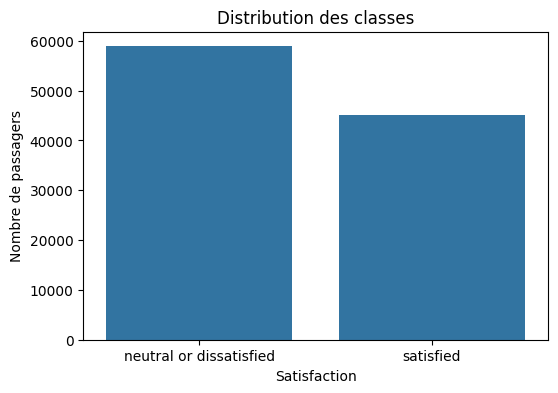

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x="satisfaction", data=df)
plt.title("Distribution des classes")
plt.xlabel("Satisfaction")
plt.ylabel("Nombre de passagers")
plt.show()



*   Histogrammes des variables numériques importantes



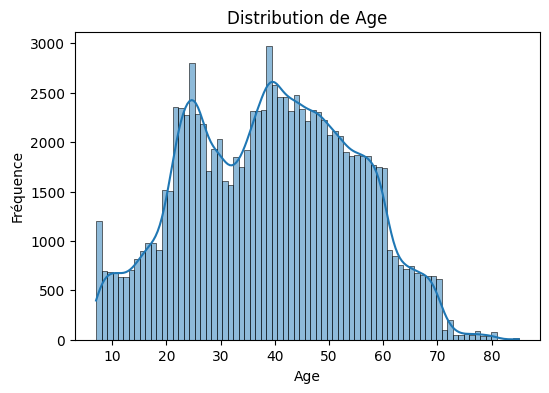

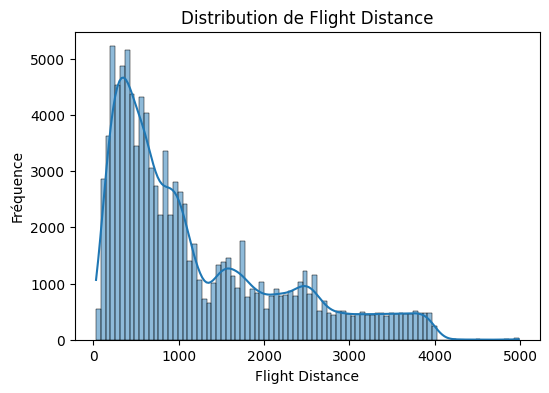

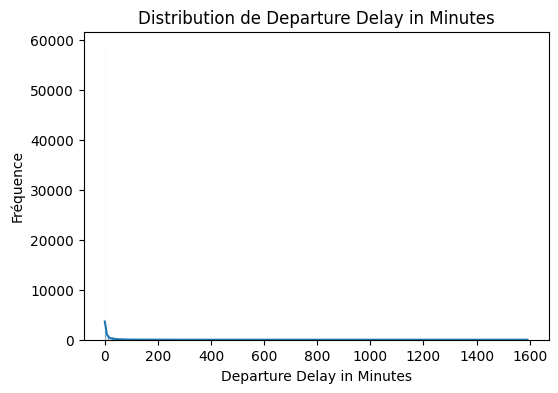

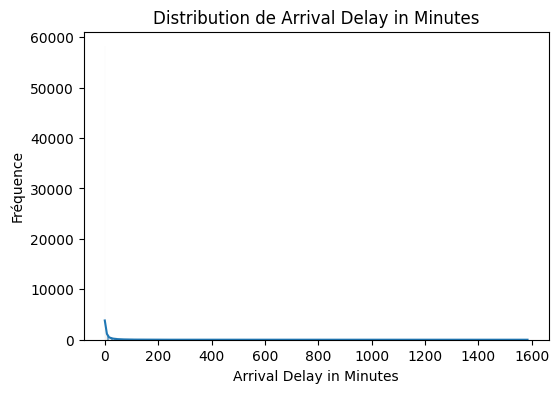

In [ ]:
numeric_cols = ["Age", "Flight Distance", "Departure Delay in Minutes", "Arrival Delay in Minutes"]

for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution de {col}")
    plt.xlabel(col)
    plt.ylabel("Fréquence")
    plt.show()

# **Nettoyage des données**



*   Remplacer les valeurs null du colonne " Arrival Delay in Minutes " par le moyenne




In [ ]:
df["Arrival Delay in Minutes"] = df["Arrival Delay in Minutes"].fillna(df["Arrival Delay in Minutes"].mean())
test_df["Arrival Delay in Minutes"] = test_df["Arrival Delay in Minutes"].fillna(test_df["Arrival Delay in Minutes"].mean())

print("Total valeurs manquantes train :", df.isnull().sum().sum())
print("Total valeurs manquantes test :", test_df.isnull().sum().sum())

Total valeurs manquantes train : 0
Total valeurs manquantes test : 0


Vérification si les valeurs null ont été remplacé ou non

In [ ]:
df.isna().sum()

,0
Unnamed: 0,0
id,0
Gender,0
Customer Type,0
Age,0
Type of Travel,0
Class,0
Flight Distance,0
Inflight wifi service,0
Departure/Arrival time convenient,0


# **Prétraitement des données**



*   Faire une copie du dataset
*   Faire l'encodage des valeurs non numérique dans les deux datasets



In [ ]:
data = df.copy()
test_data = test_df.copy()

for col in data.select_dtypes(include="object").columns:
    encoder = LabelEncoder()
    data[col] = encoder.fit_transform(data[col])
    test_data[col] = encoder.transform(test_data[col])

data.head()

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,1,0,13,1,2,460,3,4,...,5,4,3,4,4,5,5,25,18.0,0
1,1,5047,1,1,25,0,0,235,3,2,...,1,1,5,3,1,4,1,1,6.0,0
2,2,110028,0,0,26,0,0,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,1
3,3,24026,0,0,25,0,0,562,2,5,...,2,2,5,3,1,4,2,11,9.0,0
4,4,119299,1,0,61,0,0,214,3,3,...,3,3,4,4,3,3,3,0,0.0,1


# **Matrice de corrélation**



*   Afficher les relations entre les variables
*   Comprendre quelles colonnes peuvent influencer la satisfaction des passagers


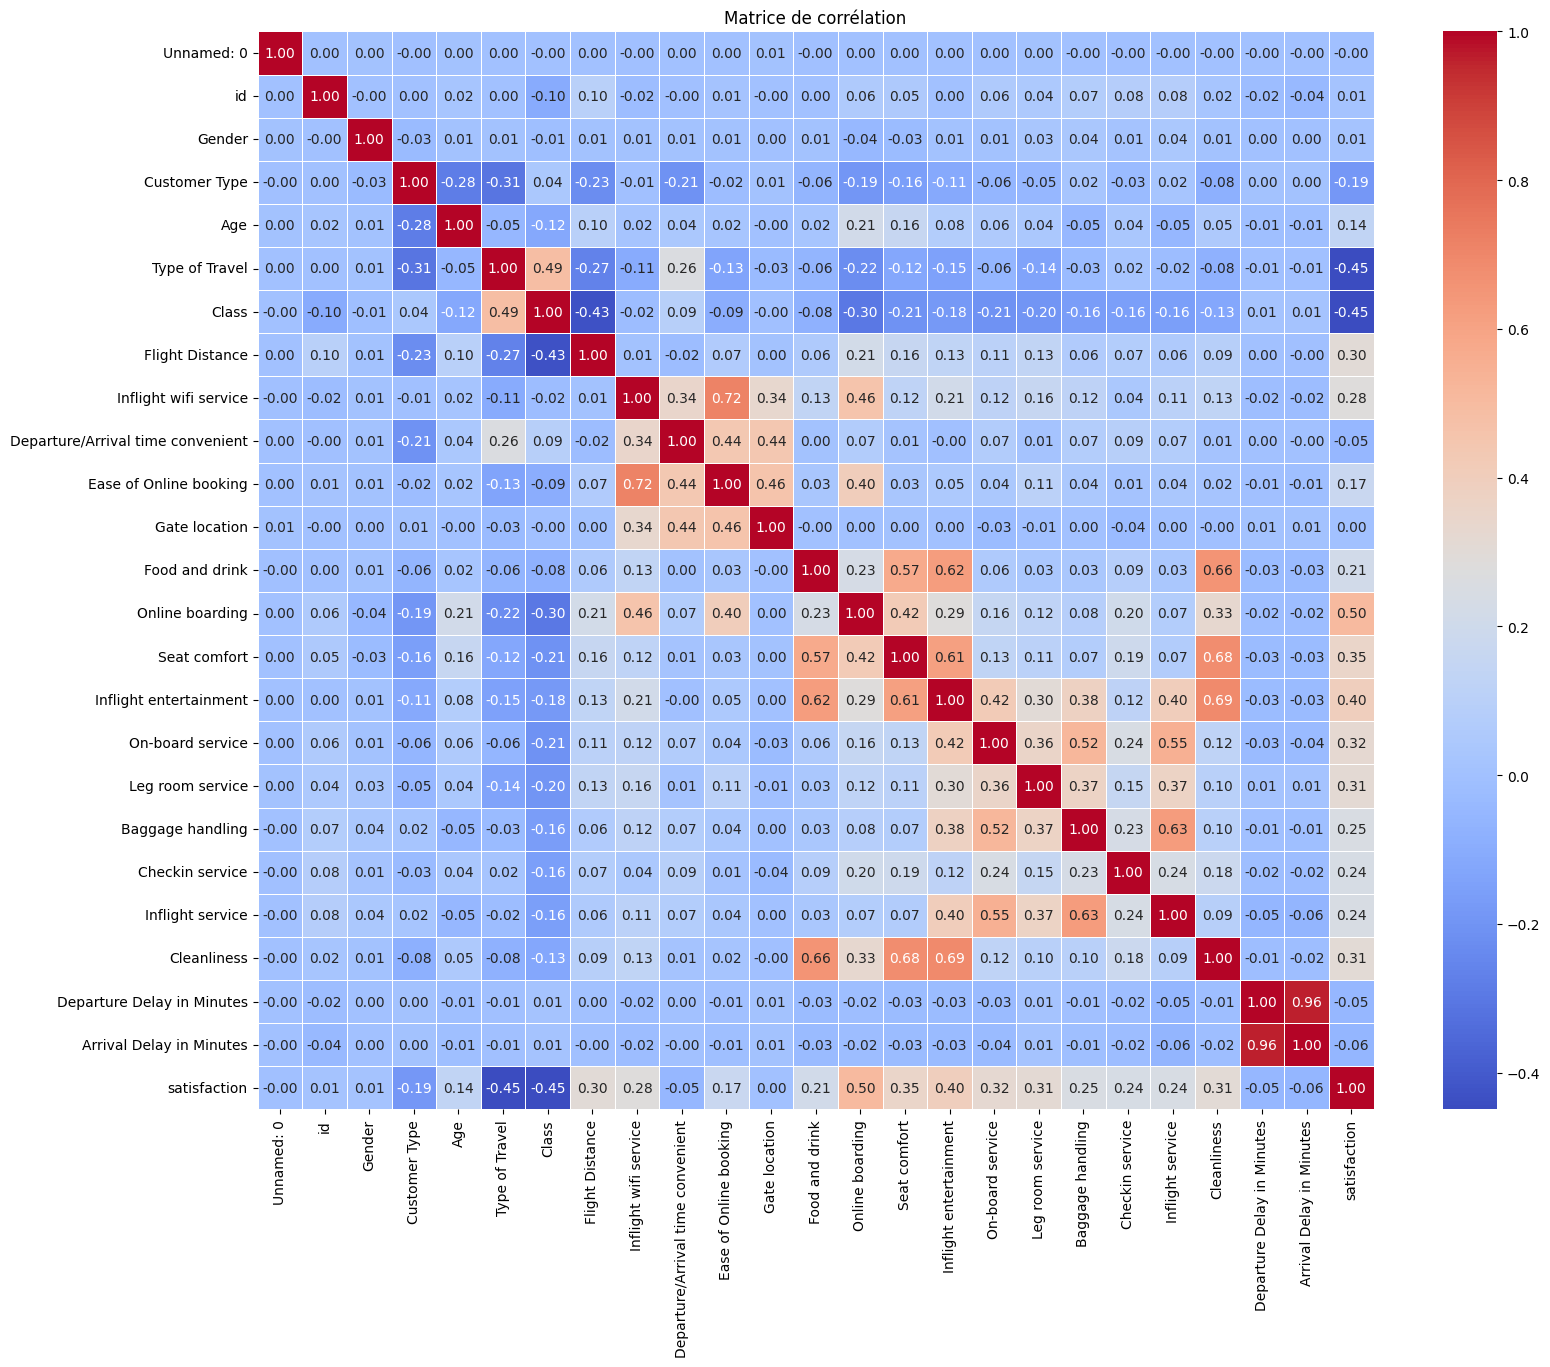

In [ ]:
corr = data.corr()

plt.figure(figsize=(18, 14))
sns.heatmap(corr,annot=True,fmt=".2f",cmap="coolwarm",linewidths=0.5)
plt.title("Matrice de corrélation")
plt.show()

# **Séparation entre x et y**

In [ ]:
x_train = data.drop("satisfaction", axis=1)
y_train = data["satisfaction"]

x_test_final = test_data.drop(columns=["satisfaction"])
y_test_final = test_data["satisfaction"]

print("Variables explicatives X :", x_train.shape)
print("Variable cible y :", y_train.shape)
x_train.head()

Variables explicatives X : (103904, 24)
Variable cible y : (103904,)


,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
0,0,70172,1,0,13,1,2,460,3,4,...,5,5,4,3,4,4,5,5,25,18.0
1,1,5047,1,1,25,0,0,235,3,2,...,1,1,1,5,3,1,4,1,1,6.0
2,2,110028,0,0,26,0,0,1142,2,2,...,5,5,4,3,4,4,4,5,0,0.0
3,3,24026,0,0,25,0,0,562,2,5,...,2,2,2,5,3,1,4,2,11,9.0
4,4,119299,1,0,61,0,0,214,3,3,...,5,3,3,4,4,3,3,3,0,0.0


# **Normalisation des données**



*   Mettre les variables numériques sur la même échelle
*   Sans normalisation, certaines variables peuvent dominer les autres


In [ ]:
scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test_final = scaler.transform(x_test_final)


# **Séléction des variables**



*   Avec SelectKBest on choisit les meilleurs colonnes originales
*   On a garder que 10 colonnes



In [ ]:
selector = SelectKBest(score_func=f_classif, k=10)

x_train = selector.fit_transform(x_train, y_train)

x_test_final = selector.transform(x_test_final)

selected_features = df.drop("satisfaction", axis=1).columns[selector.get_support()]

print(selected_features)

Index(['Type of Travel', 'Class', 'Flight Distance', 'Inflight wifi service',
       'Online boarding', 'Seat comfort', 'Inflight entertainment',
       'On-board service', 'Leg room service', 'Cleanliness'],
      dtype='object')




*   Visualisation des variables sélectionnées




In [ ]:
feature_scores = pd.DataFrame({
    "Variable": df.drop("satisfaction", axis=1).columns,
    "Score": selector.scores_
})


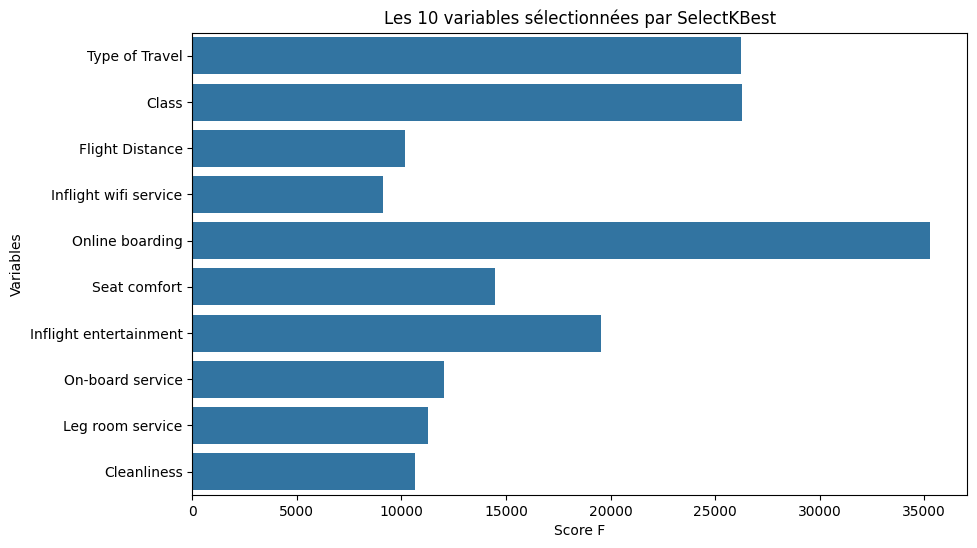

In [ ]:
selected_scores = feature_scores[
    feature_scores["Variable"].isin(selected_features)
]

plt.figure(figsize=(10,6))

sns.barplot(
    data=selected_scores,
    x="Score",
    y="Variable"
)

plt.title("Les 10 variables sélectionnées par SelectKBest")
plt.xlabel("Score F")
plt.ylabel("Variables")

plt.show()

# **Réduction de dimension avec PCA et Kernel PCA**



*   Transformer les variables en nouvelles composantes
*   Garder 95% de l'information



In [ ]:
pca = PCA(n_components=0.95, random_state=42)
x_train_pca = pca.fit_transform(x_train)

print("Nombre de composantes gardées :", pca.n_components_)
print("Variance totale conservée :", sum(pca.explained_variance_ratio_))

# Kernel PCA
n_sample = 3000

x_sample = x_train[:n_sample]
y_sample = y_train[:n_sample]

kpca = KernelPCA(
    n_components=2,
    kernel="rbf",
    gamma=0.01
)

x_train_kpca = kpca.fit_transform(x_sample)

Nombre de composantes gardées : 9
Variance totale conservée : 0.9777838972890822




*   Visualisation PCA et Kernel PCA
*   Voir si les deux classes sont bien séparées visuelement



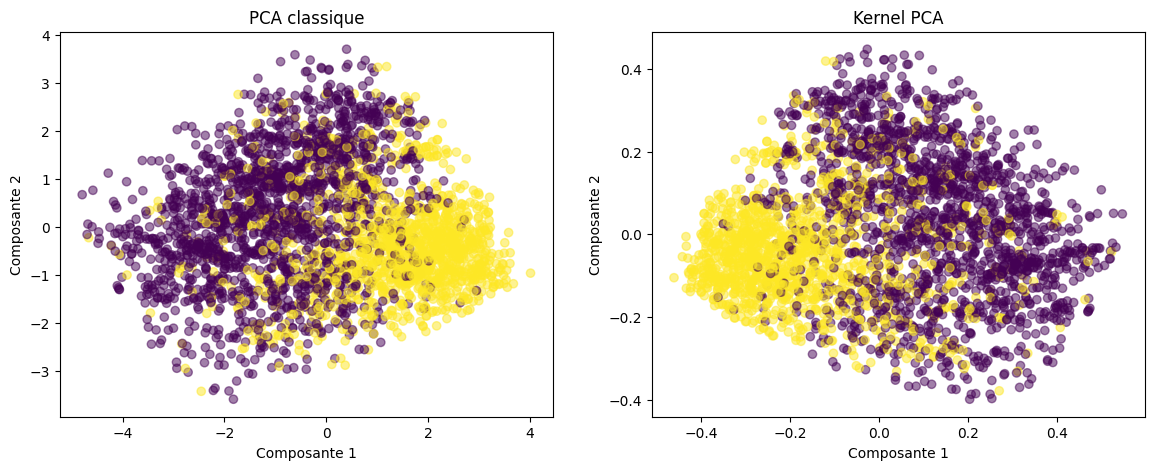

In [ ]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.scatter(
    x_train_pca[:n_sample, 0],
    x_train_pca[:n_sample, 1],
    c=y_sample,
    alpha=0.5
)
plt.title("PCA classique")
plt.xlabel("Composante 1")
plt.ylabel("Composante 2")




plt.subplot(1, 2, 2)
plt.scatter(
    x_train_kpca[:, 0],
    x_train_kpca[:, 1],
    c=y_sample,
    alpha=0.5
)
plt.title("Kernel PCA")
plt.xlabel("Composante 1")
plt.ylabel("Composante 2")

plt.show()

# **Entraînement des modèles**



*   Choisir la meilleur K pour le modèle KNN
*   Les modèles apprennent à partir des données d’entraînement.






In [ ]:
best_k = 1
best_score = 0

for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(x_train, y_train)
    prediction = knn.predict(x_test_final)
    score = accuracy_score(y_test_final, prediction)

    if score > best_score:
        best_score = score
        best_k = k

print("Meilleur K :", best_k)
print("Meilleure accuracy :", best_score)

Meilleur K : 11
Meilleure accuracy : 0.9295118570988605


In [ ]:
models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "KNN": KNeighborsClassifier(best_k)
}

for name, model in models.items():
    model.fit(x_train, y_train)
    print(name, "entraîné")

Random Forest entraîné
KNN entraîné


# **Évaluation des modèles**



*   Le modèle fait des prédictions sur le fichier test
*   Affichager l'évaluation de chaque modèle

*   Accuracy
*   Precision

*   Recall
*   F1-score











In [ ]:
results=[]

for name, model in models.items():
    prediction = model.predict(x_test_final)
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test_final, prediction),
        "Precision": precision_score(y_test_final, prediction),

        "Recall": recall_score(y_test_final, prediction),
        "F1-score": f1_score(y_test_final, prediction)
    })
results = pd.DataFrame(results)

results

,Model,Accuracy,Precision,Recall,F1-score
0,Random Forest,0.932515,0.932503,0.912304,0.922293
1,KNN,0.929512,0.944053,0.892309,0.917452


# **Matrice de confusion**



*   Choisir le meilleur modèle selon l'accuracy
*   Récupérer le modèle correspondant
*   Afficher la matrice de confusion du meilleur modèle


Meilleur modèle : Random Forest
Classification Report :
              precision    recall  f1-score   support

           0       0.93      0.95      0.94     14573
           1       0.93      0.91      0.92     11403

    accuracy                           0.93     25976
   macro avg       0.93      0.93      0.93     25976
weighted avg       0.93      0.93      0.93     25976



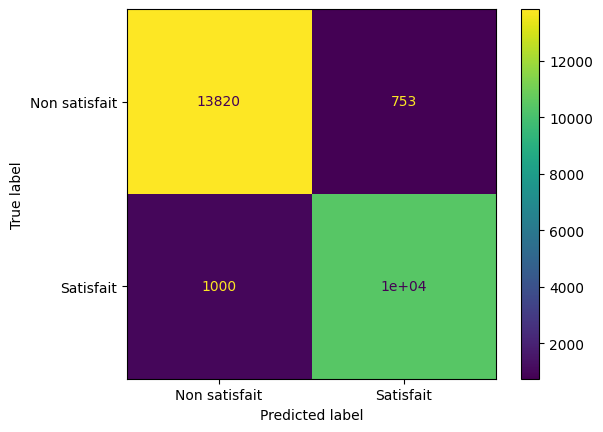

In [ ]:
best_model_name = results.loc[results["Accuracy"].idxmax(), "Model"]
print("Meilleur modèle :", best_model_name)

best_model = models[best_model_name]

prediction = best_model.predict(x_test_final)

print("Classification Report :")
print(classification_report(y_test_final, prediction))

cm = confusion_matrix(y_test_final, prediction)
ConfusionMatrixDisplay(
    cm,
    display_labels=["Non satisfait", "Satisfait"]
).plot()

plt.show()

# **Évaluation finale sur test.csv**



*   Ajouter une colonne Prediction dans le dataset de test
*   Voir les prédictios finales du meilleur modèle pour chaque passager



In [ ]:
prediction = best_model.predict(x_test_final)

test_df["Prediction"] = prediction

test_df.head()

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction,Prediction
0,0,19556,Female,Loyal Customer,52,Business travel,Eco,160,5,4,...,5,5,5,2,5,5,50,44.0,satisfied,1
1,1,90035,Female,Loyal Customer,36,Business travel,Business,2863,1,1,...,4,4,4,3,4,5,0,0.0,satisfied,1
2,2,12360,Male,disloyal Customer,20,Business travel,Eco,192,2,0,...,4,1,3,2,2,2,0,0.0,neutral or dissatisfied,0
3,3,77959,Male,Loyal Customer,44,Business travel,Business,3377,0,0,...,1,1,1,3,1,4,0,6.0,satisfied,1
4,4,36875,Female,Loyal Customer,49,Business travel,Eco,1182,2,3,...,2,2,2,4,2,4,0,20.0,satisfied,0
